In [31]:
import pulser
from pulse_counter_diabatic.counter_diabatic import CounterDiabaticPulse
import torch
import emu_mps

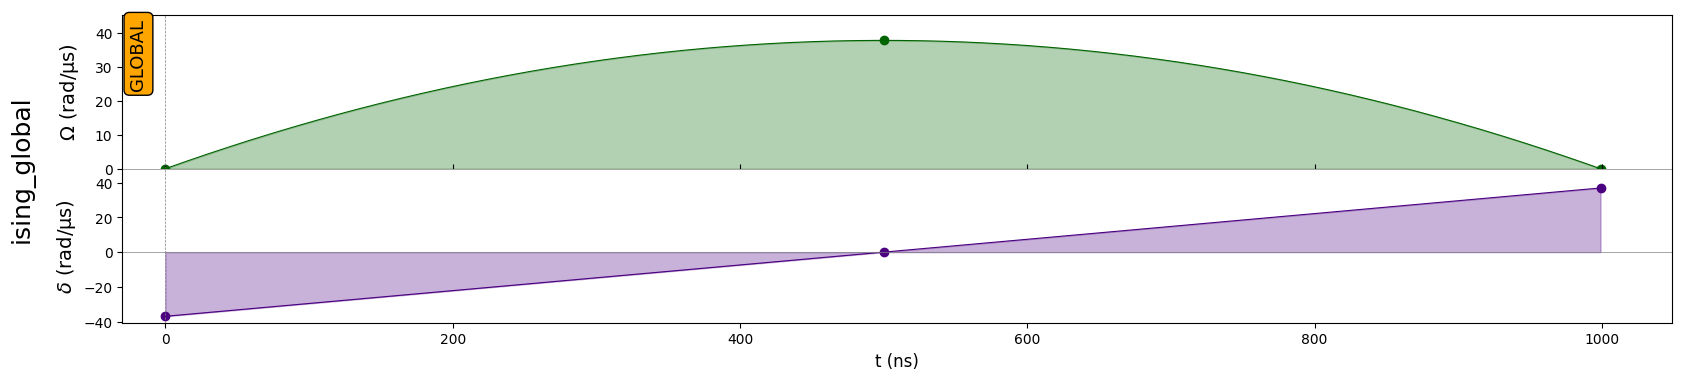

In [32]:
## pulser sequence

om_max_rabi = 1 * torch.pi * 4.0
num_atoms = 2

reg = pulser.Register.rectangle(1, num_atoms, prefix="q",spacing=7.0)

T = 1000
delta_0 = -37
delta_f = 37
adiabatic_pulse = pulser.Pulse(
    pulser.InterpolatedWaveform(T, [1e-9, 3*om_max_rabi, 1e-9]),
    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)
seq = pulser.Sequence(reg, pulser.MockDevice)
seq.declare_channel("ising_global", "rydberg_global")
seq.add(adiabatic_pulse, "ising_global")
seq.draw()

In [33]:
dt = 10
eval_times = [1.0]
mps_config = emu_mps.MPSConfig(
        dt=dt,
        precision=1e-5,
        observables=[
            emu_mps.Occupation(evaluation_times=eval_times),
            emu_mps.BitStrings(evaluation_times=eval_times, num_shots=1000),
            #emu_mps.Energy(evaluation_times=eval_times),
            #emu_mps.EnergyVariance(evaluation_times=eval_times),
            #emu_mps.EnergySecondMoment(evaluation_times=eval_times),
            #emu_mps.CorrelationMatrix(evaluation_times=eval_times),
            emu_mps.StateResult(evaluation_times=eval_times),
            #emu_mps.Fidelity(evaluation_times=eval_times, state=fidelity_state, tag_suffix="1"),
        ],
        #noise_model=noise_model,
        #interaction_cutoff=interaction_cutoff,
        #optimize_qubit_ordering=optimize_qubit_ordering,
        #solver=solver,
    log_level=100)

backend = emu_mps.MPSBackend(seq, config=mps_config)

result = backend.run()

In [34]:
ocupation = result.occupation[-1]
print(ocupation)
bitstrings = result.bitstrings[-1]
print(bitstrings)

tensor([0.5419, 0.5419], dtype=torch.float64)
Counter({'01': 482, '10': 409, '11': 98, '00': 11})


# Improving the pulse

In [35]:
cd_seq = CounterDiabaticPulse(seq,mps_config)
omega_cd, mus_cd, nus_cd = cd_seq.solver()

/home/mauro/Documents/pasqal/code/.venv/lib/python3.10/site-packages/emu_mps/mps_config.py:111: UserWarning: 'MPSConfig' was initialized without any observables. The corresponding emulation results will be empty.
  super().__init__(


In [36]:
mus_cd

tensor([[-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0.0056],
        [-0.0056, -0

In [37]:
num_atoms = 3
duration = 10
omegas_ising= torch.tensor([7.0]*num_atoms, dtype=torch.float64)
omegas_ising = torch.stack([omegas_ising]*duration, dim=0)
expected = torch.zeros_like(omegas_ising)
interaction_matrix_ising = torch.tensor([[0, 1, 2], [1, 0, 3], [2, 3, 0]], dtype=torch.float64)
for i in range(num_atoms):
    expected[:, i] = 2 * omegas_ising[:, i] + 2 * interaction_matrix_ising[i].sum()
expected

tensor([[20., 22., 24.],
        [20., 22., 24.],
        [20., 22., 24.],
        [20., 22., 24.],
        [20., 22., 24.],
        [20., 22., 24.],
        [20., 22., 24.],
        [20., 22., 24.],
        [20., 22., 24.],
        [20., 22., 24.]], dtype=torch.float64)

In [38]:
mat1 = torch.tensor([[0,1,2],[3,4,5],[6,7,8]])
mat1[1].sum()

tensor(12)